# 03 — Exploratory Data Analysis

This notebook explores the cleaned data to understand:
- Target variable distribution (games_missed)
- Feature relationships with injury risk
- Temporal patterns in injuries
- Data quality and coverage

**Input:** Processed files from `data/processed/` (produced by NB02)

**Output:**
- `data/processed/analysis_merged.csv` — unified player-season dataset for feature engineering
- Publication-quality figures saved to `figures/`

---

### TL;DR

- **Target (games_missed):** Mean ~1.67, median 1, highly right-skewed, ~48% zeros
- **Strongest predictor:** Minutes played (r≈0.220)
- **Key insight:** Players injured last season have **~1.5x higher risk** of injury the following season
- **Collinearity:** pts, tov, stl, ast all driven by minutes — choose carefully in feature engineering

In [1]:
import sys
sys.path.append('..')

import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import (
    FIRST_SEASON, LAST_SEASON,
    PROCESSED_DIR,
    TARGET_COL,
    RANDOM_SEED
)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Ensure figures directory exists
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Season range: {FIRST_SEASON} to {LAST_SEASON}")
print(f"Target variable: {TARGET_COL}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Season range: 2010 to 2019
Target variable: games_missed_next_season
Figures will be saved to: ../figures


---
## Section 1: Load and Merge Data

We load the cleaned datasets from NB02 and merge them into a single analysis DataFrame. The merge links injury history (target variable) and player bio data to per-season player stats using `player_id` and `season` as keys. This unified DataFrame is the basis for all EDA below.

In [2]:
# Load all processed datasets
print("Loading processed datasets...")
print("=" * 60)

df_injuries = pd.read_csv(f'../{PROCESSED_DIR}/injury_history_by_player_season.csv')
print(f"Injury history: {df_injuries.shape}")

df_stats = pd.read_csv(f'../{PROCESSED_DIR}/player_stats_combined.csv')
print(f"Player stats: {df_stats.shape}")

df_bio = pd.read_csv(f'../{PROCESSED_DIR}/player_bio_combined.csv')
print(f"Player bio: {df_bio.shape}")

df_mapping = pd.read_csv(f'../{PROCESSED_DIR}/player_id_mapping.csv')
print(f"Player ID mapping: {df_mapping.shape}")

Loading processed datasets...
Injury history: (2622, 7)
Player stats: (4934, 70)
Player bio: (4934, 26)
Player ID mapping: (843, 5)


> **Note on 2019-20 season:** The elap733 injury data ends July 2019. The 2019-20 season has only 1 game missed in the injury data and will be excluded or flagged during feature engineering. EDA findings below include this season but it does not materially affect distributions or correlations.

In [3]:
# Examine the datasets
print("\nInjury data sample:")
print(df_injuries.head())
print(f"\nColumns: {list(df_injuries.columns)}")


Injury data sample:
    player_name   season  season_start_year  games_missed  injury_events                                   injury_types        teams
0    A.j. Price  2011-12               2011             2              1                                             []   ['Pacers']
1    A.j. Price  2012-13               2012            15              4  ['sore', 'hand', 'knee', 'fracture', 'groin']  ['Wizards']
2  Aaron Brooks  2012-13               2012             1              1                              ['sore', 'ankle']    ['Kings']
3  Aaron Brooks  2013-14               2013             1              1                         ['tendinitis', 'knee']  ['Rockets']
4  Aaron Brooks  2015-16               2015             2              1                        ['strain', 'hamstring']    ['Bulls']

Columns: ['player_name', 'season', 'season_start_year', 'games_missed', 'injury_events', 'injury_types', 'teams']


In [4]:
print("\nPlayer stats sample:")
print(df_stats[['player_id', 'player_name', 'season', 'age', 'gp', 'min', 'pts']].head())


Player stats sample:
   player_id    player_name   season   age  gp   min   pts
0     201985       AJ Price  2010-11  24.0  50  15.9   6.5
1     201166   Aaron Brooks  2010-11  26.0  59  21.8  10.7
2     201189     Aaron Gray  2010-11  26.0  41  12.9   3.1
3     201151       Acie Law  2010-11  26.0  51  14.2   4.2
4       1733  Al Harrington  2010-11  31.0  73  22.8  10.5


In [5]:
# Create unified analysis dataframe
print("\nCreating unified analysis dataframe...")

# First, add NBA player_id to injury data using mapping
df_injuries_with_id = df_injuries.merge(
    df_mapping[['injury_player_name', 'nba_player_id']],
    left_on='player_name',
    right_on='injury_player_name',
    how='left'
)
print(f"Injuries with ID: {df_injuries_with_id.shape[0]} rows, {df_injuries_with_id['nba_player_id'].notna().sum()} matched")

# Merge with player stats
df_analysis = df_stats.merge(
    df_injuries_with_id[['nba_player_id', 'season', 'games_missed', 'injury_events', 'injury_types']],
    left_on=['player_id', 'season'],
    right_on=['nba_player_id', 'season'],
    how='left'
)

# Fill missing games_missed with 0 (players who weren't injured)
df_analysis['games_missed'] = df_analysis['games_missed'].fillna(0).astype(int)
df_analysis['injury_events'] = df_analysis['injury_events'].fillna(0).astype(int)

print(f"\nAfter merging with stats: {df_analysis.shape}")


Creating unified analysis dataframe...
Injuries with ID: 2622 rows, 2614 matched

After merging with stats: (4935, 74)


In [6]:
# Merge with bio data (include advanced rate stats: usg_pct, ts_pct, etc.)
bio_cols = ['player_id', 'season', 'player_height_inches', 'player_weight',
            'country', 'draft_year', 'draft_round',
            'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']

df_analysis = df_analysis.merge(
    df_bio[bio_cols],
    on=['player_id', 'season'],
    how='left'
)
print(f"After merging with bio: {df_analysis.shape}")

After merging with bio: (4935, 85)


In [7]:
# Summary statistics
print("\n" + "=" * 60)
print("UNIFIED DATASET SUMMARY")
print("=" * 60)
print(f"Total player-seasons: {len(df_analysis)}")
print(f"Unique players: {df_analysis['player_id'].nunique()}")
print(f"Seasons covered: {sorted(df_analysis['season'].unique())}")
print(f"\nPlayer-seasons with injuries: {(df_analysis['games_missed'] > 0).sum()} ({(df_analysis['games_missed'] > 0).mean()*100:.1f}%)")
print(f"Player-seasons without injuries: {(df_analysis['games_missed'] == 0).sum()} ({(df_analysis['games_missed'] == 0).mean()*100:.1f}%)")


UNIFIED DATASET SUMMARY
Total player-seasons: 4935
Unique players: 1302
Seasons covered: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20']

Player-seasons with injuries: 2562 (51.9%)
Player-seasons without injuries: 2373 (48.1%)


---
## Section 2: Target Variable Analysis (games_missed)

We examine the target distribution to understand its shape (zero-inflation, skewness) which will inform our choice of model and evaluation metrics. A heavily skewed, zero-inflated target suggests that standard linear regression may not be ideal — we may need robust regression, a two-stage model (predict injury yes/no, then severity), or appropriate transformations.

In [8]:
# Target variable statistics
print("TARGET VARIABLE: games_missed")
print("=" * 60)
print(f"\nBasic Statistics:")
print(df_analysis['games_missed'].describe())
print(f"\nSkewness: {df_analysis['games_missed'].skew():.2f}")
print(f"Kurtosis: {df_analysis['games_missed'].kurtosis():.2f}")
print(f"\nZero-inflation: {(df_analysis['games_missed'] == 0).mean()*100:.1f}% of player-seasons have 0 games missed")

TARGET VARIABLE: games_missed

Basic Statistics:
count    4935.000000
mean        1.673961
std         3.165109
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        40.000000
Name: games_missed, dtype: float64

Skewness: 4.48
Kurtosis: 30.46

Zero-inflation: 48.1% of player-seasons have 0 games missed


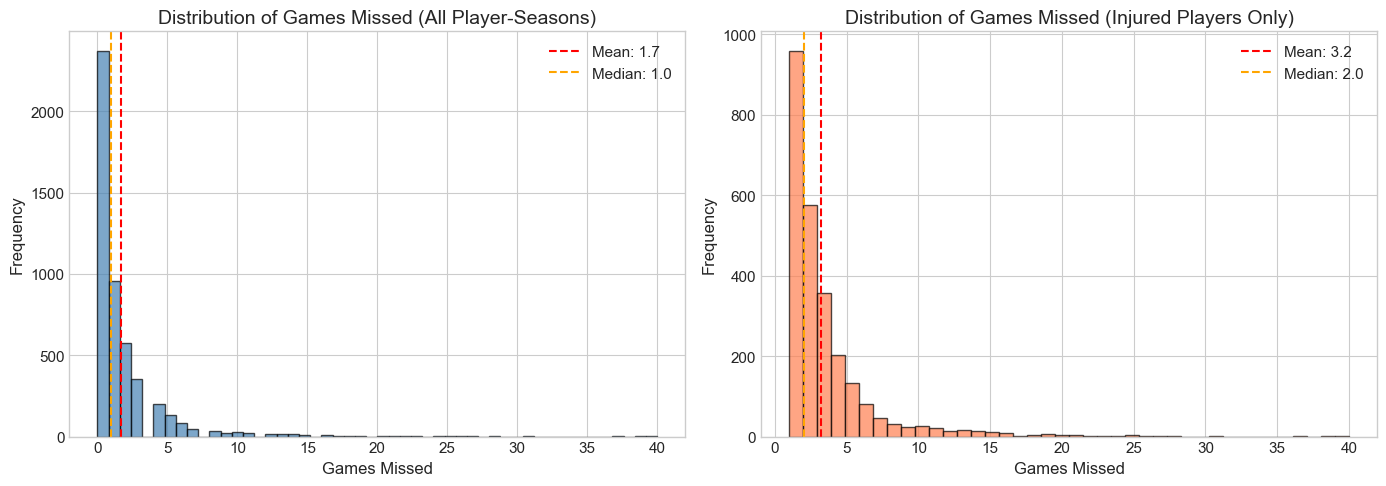

Saved: ../figures/target_distribution.png


In [9]:
# Distribution of games_missed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular histogram
ax1 = axes[0]
ax1.hist(df_analysis['games_missed'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Games Missed')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Games Missed (All Player-Seasons)')
ax1.axvline(df_analysis['games_missed'].mean(), color='red', linestyle='--', label=f'Mean: {df_analysis["games_missed"].mean():.1f}')
ax1.axvline(df_analysis['games_missed'].median(), color='orange', linestyle='--', label=f'Median: {df_analysis["games_missed"].median():.1f}')
ax1.legend()

# Histogram excluding zeros
ax2 = axes[1]
injured_only = df_analysis[df_analysis['games_missed'] > 0]['games_missed']
ax2.hist(injured_only, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Games Missed')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Games Missed (Injured Players Only)')
ax2.axvline(injured_only.mean(), color='red', linestyle='--', label=f'Mean: {injured_only.mean():.1f}')
ax2.axvline(injured_only.median(), color='orange', linestyle='--', label=f'Median: {injured_only.median():.1f}')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/target_distribution.png")

In [10]:
# Games missed by season - trend analysis
season_injury_stats = df_analysis.groupby('season').agg({
    'games_missed': ['sum', 'mean', 'median'],
    'player_id': 'count'
}).round(2)
season_injury_stats.columns = ['total_games_missed', 'mean_games_missed', 'median_games_missed', 'player_count']
season_injury_stats = season_injury_stats.reset_index()

print("Games Missed by Season:")
print(season_injury_stats)

Games Missed by Season:
    season  total_games_missed  mean_games_missed  median_games_missed  player_count
0  2010-11                 813               1.80                  1.0           452
1  2011-12                1302               2.72                  1.0           478
2  2012-13                1218               2.60                  1.0           469
3  2013-14                1722               3.57                  1.0           482
4  2014-15                 611               1.24                  1.0           492
5  2015-16                 710               1.49                  1.0           477
6  2016-17                 719               1.48                  1.0           486
7  2017-18                 610               1.13                  1.0           540
8  2018-19                 556               1.05                  1.0           530
9  2019-20                   0               0.00                  0.0           529


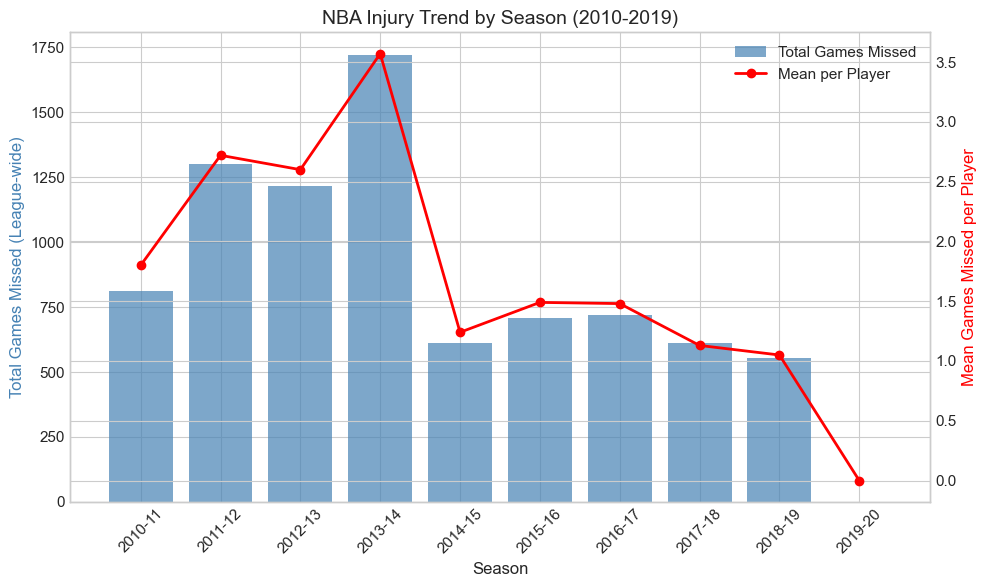

Saved: ../figures/injury_trend_by_season.png


In [11]:
# Trend plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(season_injury_stats['season'], season_injury_stats['total_games_missed'],
       color='steelblue', alpha=0.7, label='Total Games Missed')

ax2 = ax.twinx()
ax2.plot(season_injury_stats['season'], season_injury_stats['mean_games_missed'],
         color='red', marker='o', linewidth=2, label='Mean per Player')

ax.set_xlabel('Season')
ax.set_ylabel('Total Games Missed (League-wide)', color='steelblue')
ax2.set_ylabel('Mean Games Missed per Player', color='red')
ax.set_title('NBA Injury Trend by Season (2010-2019)')
ax.tick_params(axis='x', rotation=45)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_trend_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_trend_by_season.png")

In [12]:
# Create age groups
df_analysis['age_group'] = pd.cut(
    df_analysis['age'],
    bins=[0, 25, 30, 100],
    labels=['Under 25', '25-30', 'Over 30']
)

# Create position groups based on height (approximation without raw position data)
df_analysis['position_group'] = pd.cut(
    df_analysis['player_height_inches'].fillna(df_analysis['player_height_inches'].median()),
    bins=[0, 76, 81, 100],
    labels=['Guard (G)', 'Forward (F)', 'Center (C)']
)

print("Age group distribution:")
print(df_analysis['age_group'].value_counts())
print("\nPosition group distribution:")
print(df_analysis['position_group'].value_counts())

Age group distribution:
age_group
Under 25    2216
25-30       1734
Over 30      985
Name: count, dtype: int64

Position group distribution:
position_group
Forward (F)    2385
Center (C)     1301
Guard (G)      1249
Name: count, dtype: int64


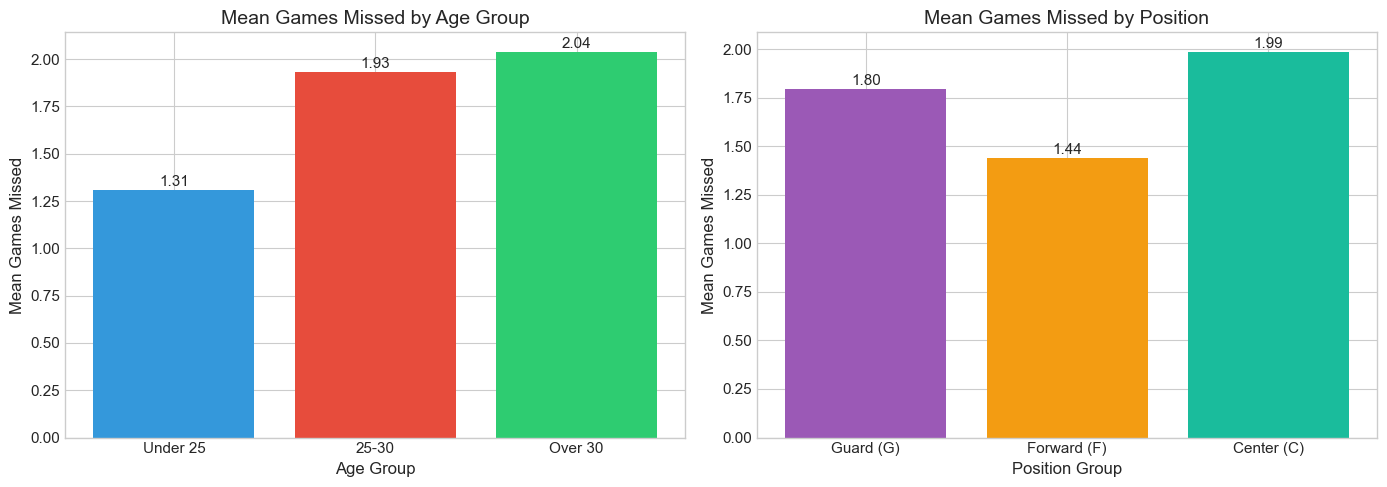

In [13]:
# Games missed by age group and position
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By age group
age_injury = df_analysis.groupby('age_group', observed=False)['games_missed'].mean()
axes[0].bar(age_injury.index.astype(str), age_injury.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Games Missed')
axes[0].set_title('Mean Games Missed by Age Group')
for i, v in enumerate(age_injury.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

# By position
pos_injury = df_analysis.groupby('position_group', observed=False)['games_missed'].mean()
axes[1].bar(pos_injury.index.astype(str), pos_injury.values, color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1].set_xlabel('Position Group')
axes[1].set_ylabel('Mean Games Missed')
axes[1].set_title('Mean Games Missed by Position')
for i, v in enumerate(pos_injury.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

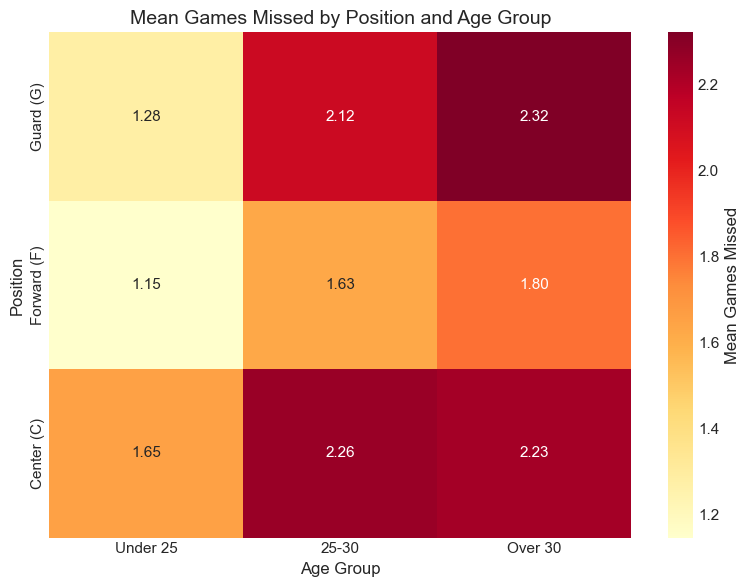

Saved: ../figures/injury_by_age_position.png


In [14]:
# Heatmap: Games missed by position x age group
pivot_table = df_analysis.pivot_table(observed=False,
    values='games_missed',
    index='position_group',
    columns='age_group',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Mean Games Missed'})
ax.set_title('Mean Games Missed by Position and Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Position')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_by_age_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_by_age_position.png")

---
## Section 3: Feature Distributions

We inspect the distributions of key predictor variables to identify skewness, outliers, and data quality issues. Understanding feature distributions helps decide whether transformations (e.g., log, Box-Cox) are needed and which features may require special handling in modeling.

In [15]:
# Key features to analyze
key_features = ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'usg_pct', 'player_weight']

# Check which features exist
available_features = [f for f in key_features if f in df_analysis.columns]
print(f"Analyzing features: {available_features}")

Analyzing features: ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'usg_pct', 'player_weight']


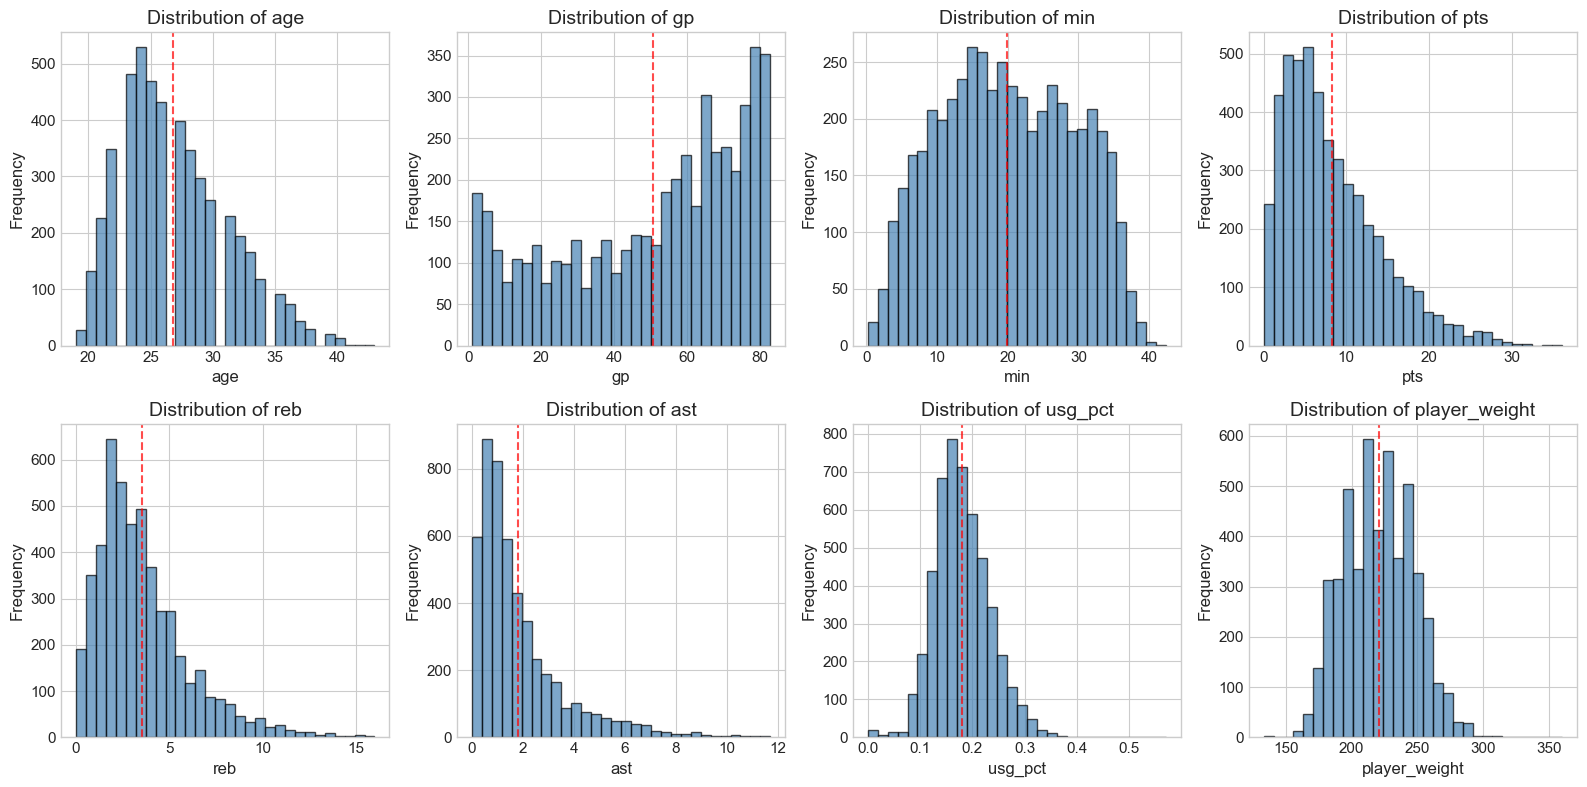

In [16]:
# Distribution plots for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    ax = axes[i]
    data = df_analysis[feature].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7)

# Hide unused subplots
for j in range(len(available_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
# Check for outliers
print("\nPotential Outliers (values beyond 3 std):")
for feature in available_features:
    data = df_analysis[feature].dropna()
    mean, std = data.mean(), data.std()
    outliers = data[(data < mean - 3*std) | (data > mean + 3*std)]
    if len(outliers) > 0:
        print(f"  {feature}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)")


Potential Outliers (values beyond 3 std):
  age: 18 outliers (0.36%)
  pts: 59 outliers (1.20%)
  reb: 80 outliers (1.62%)
  ast: 100 outliers (2.03%)
  usg_pct: 41 outliers (0.83%)
  player_weight: 9 outliers (0.18%)


---
## Section 4: Correlation Analysis

We compute pairwise Pearson correlations to identify which features are most linearly associated with `games_missed` and to detect multicollinearity among predictors. High collinearity (e.g., pts and minutes) means we should be selective about which features enter the model together.

In [18]:
# Select numeric columns for correlation analysis
numeric_cols = ['games_missed', 'age', 'gp', 'min', 'pts', 'reb', 'ast', 'tov', 'stl', 'blk',
                'fg_pct', 'fg3_pct', 'ft_pct', 'plus_minus', 'player_weight', 'player_height_inches',
                'usg_pct', 'ts_pct']

# Keep only columns that exist
numeric_cols = [c for c in numeric_cols if c in df_analysis.columns]

# Calculate correlation matrix
corr_matrix = df_analysis[numeric_cols].corr()

# Correlation with target
target_corr = corr_matrix['games_missed'].drop('games_missed').sort_values(key=abs, ascending=False)
print("Correlation with games_missed (sorted by absolute value):")
print(target_corr.round(3))

Correlation with games_missed (sorted by absolute value):
min                     0.220
tov                     0.205
pts                     0.180
stl                     0.159
ast                     0.148
reb                     0.145
usg_pct                 0.124
age                     0.094
blk                     0.088
ft_pct                  0.086
gp                      0.056
fg_pct                  0.045
ts_pct                  0.043
player_weight           0.034
fg3_pct                 0.020
player_height_inches    0.016
plus_minus             -0.012
Name: games_missed, dtype: float64


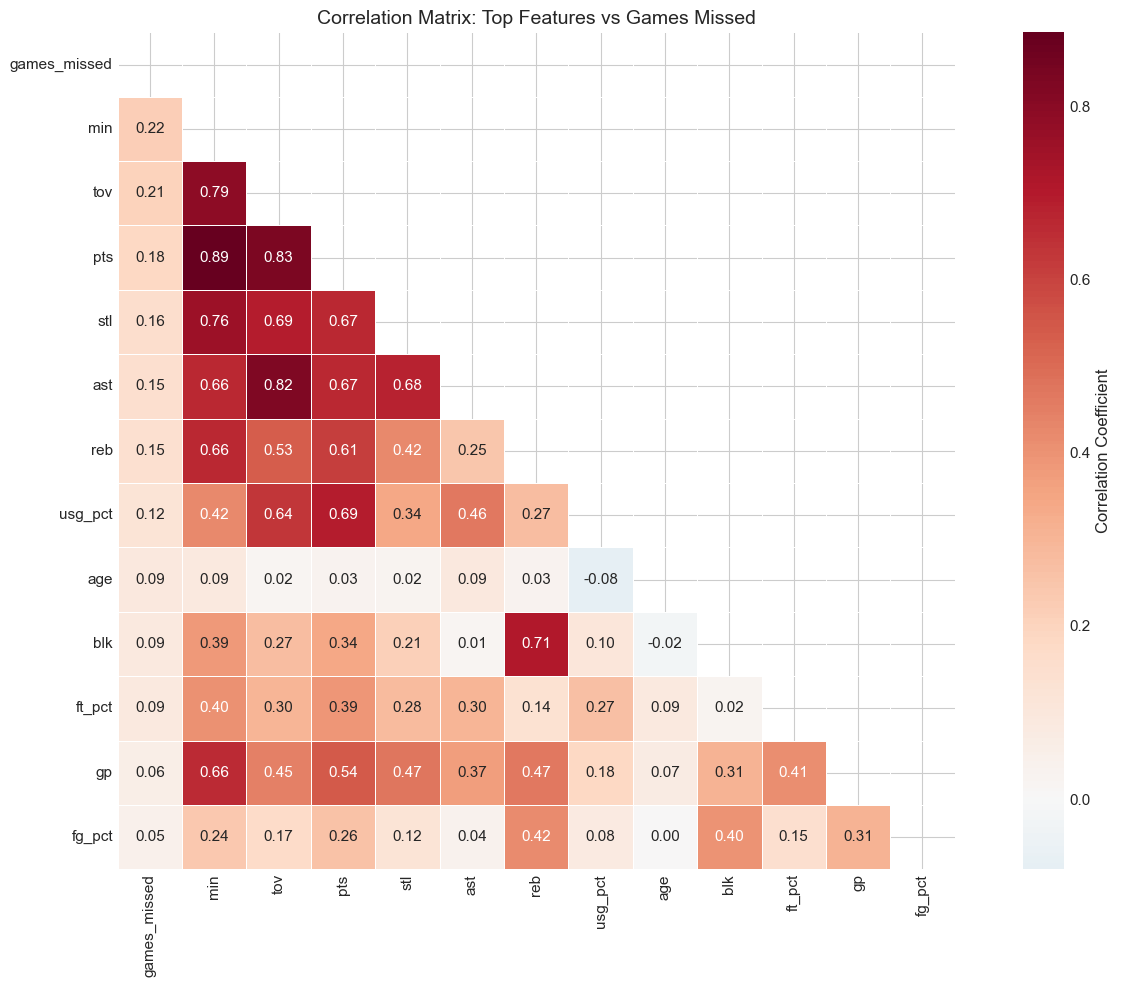

Saved: ../figures/correlation_heatmap.png


In [19]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Use only top correlated features for cleaner visualization
top_features = ['games_missed'] + list(target_corr.head(12).index)
corr_subset = df_analysis[top_features].corr()

mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix: Top Features vs Games Missed')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/correlation_heatmap.png")

In [20]:
# Create prior season injury feature for key hypothesis test
df_analysis = df_analysis.sort_values(['player_id', 'season_start_year'])
df_analysis['games_missed_last_season'] = df_analysis.groupby('player_id')['games_missed'].shift(1)

# Calculate correlation
prior_injury_corr = df_analysis[['games_missed', 'games_missed_last_season']].dropna().corr().iloc[0, 1]
print(f"\nCorrelation between prior season injury and current season injury: {prior_injury_corr:.3f}")


Correlation between prior season injury and current season injury: 0.213


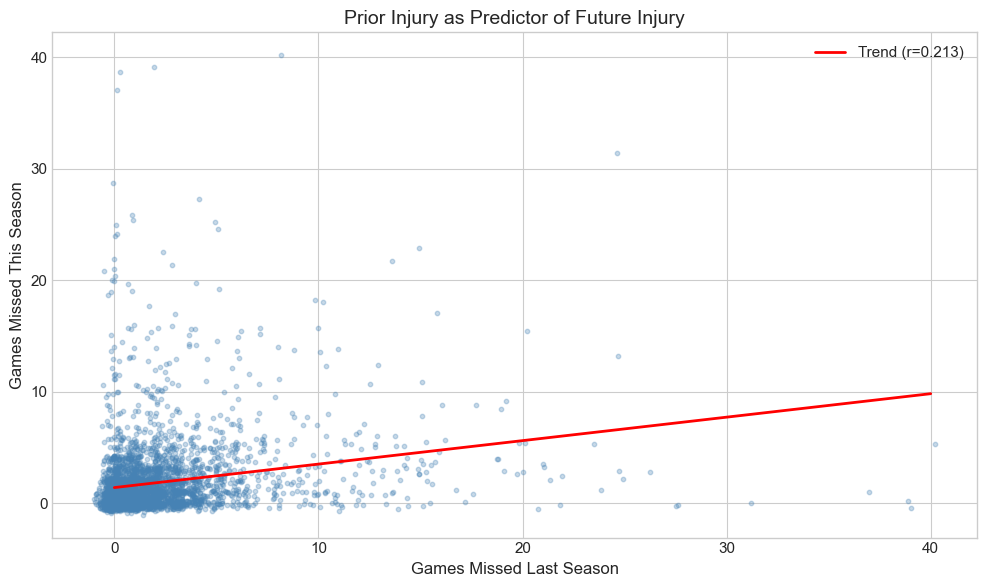

Saved: ../figures/prior_injury_vs_future.png


In [21]:
# Prior injury vs future injury scatter plot
df_prior = df_analysis.dropna(subset=['games_missed_last_season'])

fig, ax = plt.subplots(figsize=(10, 6))

# Add jitter for better visualization
x = df_prior['games_missed_last_season'] + np.random.normal(0, 0.3, len(df_prior))
y = df_prior['games_missed'] + np.random.normal(0, 0.3, len(df_prior))

ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')

# Add trend line
z = np.polyfit(df_prior['games_missed_last_season'], df_prior['games_missed'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df_prior['games_missed_last_season'].max(), 100)
ax.plot(x_line, p(x_line), "r-", linewidth=2, label=f'Trend (r={prior_injury_corr:.3f})')

ax.set_xlabel('Games Missed Last Season')
ax.set_ylabel('Games Missed This Season')
ax.set_title('Prior Injury as Predictor of Future Injury')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prior_injury_vs_future.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/prior_injury_vs_future.png")

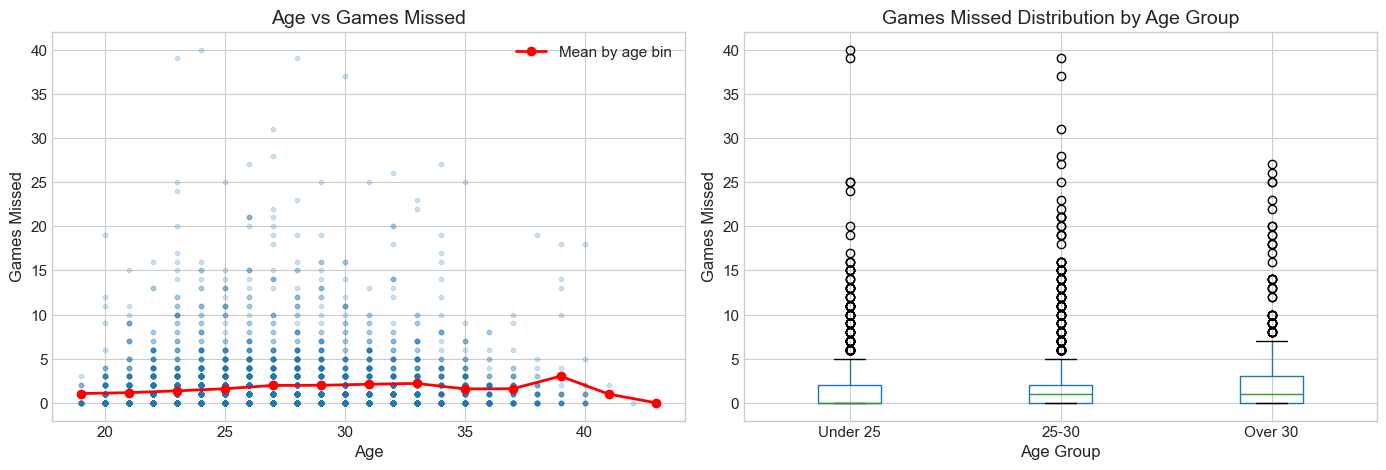

In [22]:
# Age vs injury risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with trend
ax1 = axes[0]
age_data = df_analysis[['age', 'games_missed']].dropna()
ax1.scatter(age_data['age'], age_data['games_missed'], alpha=0.2, s=10)

# Bin by age and plot means
age_bins = df_analysis.groupby(pd.cut(df_analysis['age'], bins=range(18, 45, 2)), observed=False)['games_missed'].mean()
ax1.plot([b.mid for b in age_bins.index], age_bins.values, 'r-', linewidth=2, marker='o', label='Mean by age bin')
ax1.set_xlabel('Age')
ax1.set_ylabel('Games Missed')
ax1.set_title('Age vs Games Missed')
ax1.legend()

# Box plot by age group
ax2 = axes[1]
df_analysis.boxplot(column='games_missed', by='age_group', ax=ax2)
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Games Missed')
ax2.set_title('Games Missed Distribution by Age Group')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

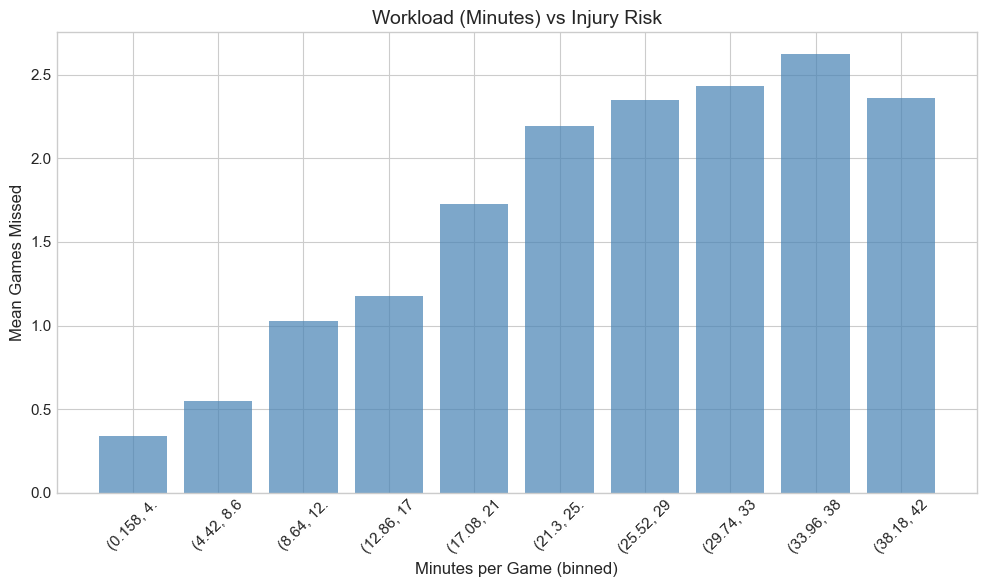

Saved: ../figures/workload_vs_injury.png


In [23]:
# Workload (minutes) vs injury risk
fig, ax = plt.subplots(figsize=(10, 6))

# Bin by minutes and plot
min_bins = df_analysis.groupby(pd.cut(df_analysis['min'], bins=10), observed=False)['games_missed'].agg(['mean', 'count'])
min_bins = min_bins[min_bins['count'] > 20]  # Only bins with enough data

ax.bar([str(b)[:10] for b in min_bins.index], min_bins['mean'], color='steelblue', alpha=0.7)
ax.set_xlabel('Minutes per Game (binned)')
ax.set_ylabel('Mean Games Missed')
ax.set_title('Workload (Minutes) vs Injury Risk')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'workload_vs_injury.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/workload_vs_injury.png")

---
## Section 5: Injury History Deep Dive

We look at individual-level injury patterns to understand who gets injured most frequently and whether injuries recur. The "repeat injury" analysis tests our key hypothesis: does being injured in one season increase the probability of injury in the next season?

In [24]:
# Players with most total games missed
player_total_injuries = df_analysis.groupby(['player_id', 'player_name']).agg({
    'games_missed': 'sum',
    'injury_events': 'sum',
    'season': 'count'
}).reset_index()
player_total_injuries.columns = ['player_id', 'player_name', 'total_games_missed', 'total_injury_events', 'seasons_played']
player_total_injuries['games_missed_per_season'] = player_total_injuries['total_games_missed'] / player_total_injuries['seasons_played']

top_20_injured = player_total_injuries.nlargest(20, 'total_games_missed')
print("Top 20 Most Injury-Prone Players (2010-2019):")
print(top_20_injured[['player_name', 'total_games_missed', 'total_injury_events', 'seasons_played', 'games_missed_per_season']].to_string(index=False))

Top 20 Most Injury-Prone Players (2010-2019):
     player_name  total_games_missed  total_injury_events  seasons_played  games_missed_per_season
      Kevin Love                  77                   36              10                 7.700000
     Jason Smith                  68                   13               9                 7.555556
     Eric Gordon                  63                   30              10                 6.300000
   Jordan Farmar                  61                    8               6                10.166667
   Jameer Nelson                  57                   33               8                 7.125000
   Anthony Davis                  56                   35               8                 7.000000
    Trevor Ariza                  54                   20              10                 5.400000
        CJ Miles                  52                   26              10                 5.200000
            Nene                  50                   33      

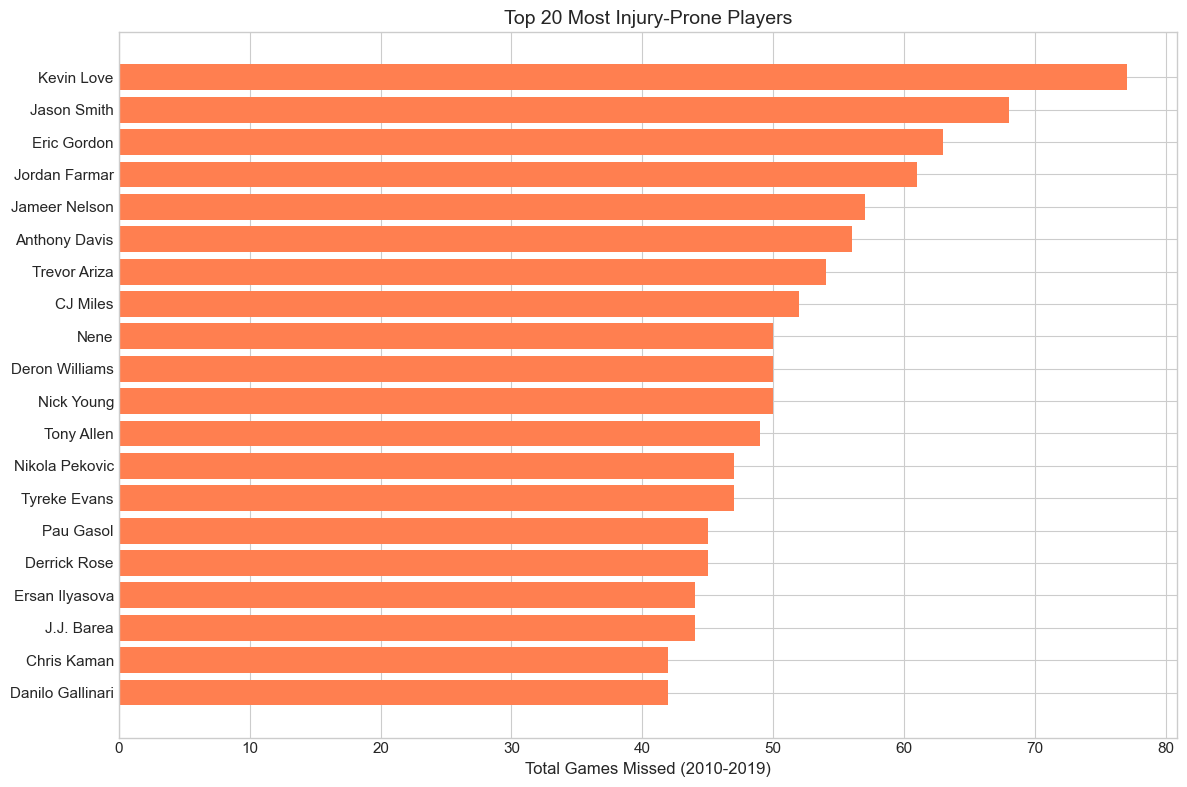

In [25]:
# Plot top 20
fig, ax = plt.subplots(figsize=(12, 8))

top_20_injured_sorted = top_20_injured.sort_values('total_games_missed', ascending=True)
ax.barh(top_20_injured_sorted['player_name'], top_20_injured_sorted['total_games_missed'], color='coral')
ax.set_xlabel('Total Games Missed (2010-2019)')
ax.set_title('Top 20 Most Injury-Prone Players')

plt.tight_layout()
plt.show()

In [26]:
# Repeat injury analysis: consecutive season injuries
df_analysis['injured_this_season'] = (df_analysis['games_missed'] > 0).astype(int)
df_analysis['injured_last_season'] = df_analysis.groupby('player_id')['injured_this_season'].shift(1)

# Calculate repeat injury rate
df_with_prior = df_analysis.dropna(subset=['injured_last_season'])
repeat_injury_rate = df_with_prior.groupby('injured_last_season')['injured_this_season'].mean()

print("Repeat Injury Analysis:")
print(f"  If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% chance of injury this season")
print(f"  If injured last season: {repeat_injury_rate[1]*100:.1f}% chance of injury this season")
print(f"  Relative risk increase: {repeat_injury_rate[1]/repeat_injury_rate[0]:.2f}x")

Repeat Injury Analysis:
  If NOT injured last season: 43.1% chance of injury this season
  If injured last season: 64.2% chance of injury this season
  Relative risk increase: 1.49x


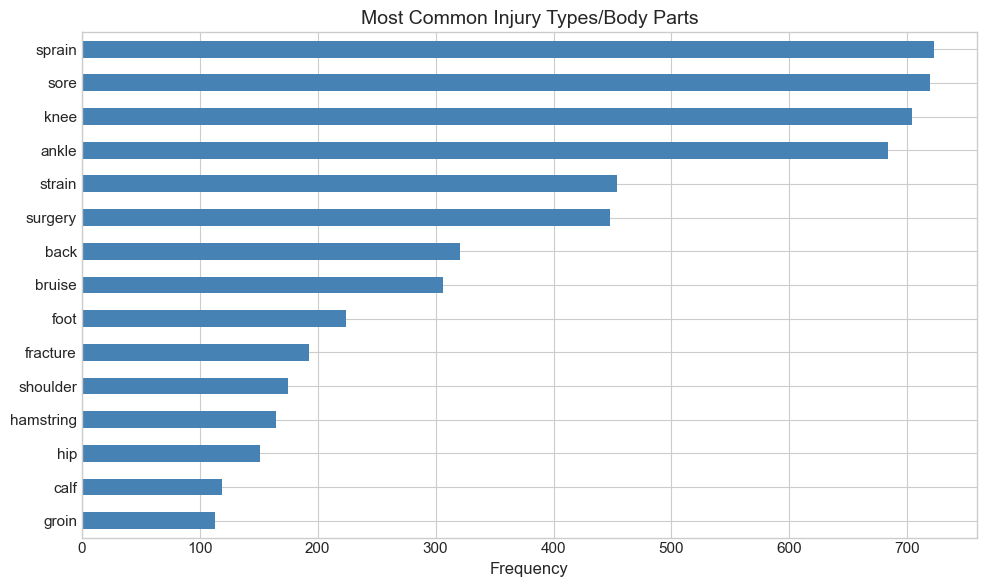

In [27]:
# Injury types analysis (from original injury data)
if 'injury_types' in df_injuries.columns:
    # Flatten injury types
    all_injury_types = []
    for types in df_injuries['injury_types'].dropna():
        if isinstance(types, str):
            # Parse string representation of list safely
            types = ast.literal_eval(types)
        all_injury_types.extend(types)

    # Count frequencies
    injury_type_counts = pd.Series(all_injury_types).value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    injury_type_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Frequency')
    ax.set_title('Most Common Injury Types/Body Parts')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

---
## Section 6: Temporal Patterns

We examine how injuries vary across seasons to identify league-wide trends (e.g., rising injury rates) and account for structural anomalies like the 2011-12 lockout-shortened season (66 games instead of 82). Temporal trends can inform whether season-level controls are needed in models.

In [28]:
# League-wide injury trends
season_stats = df_analysis.groupby('season').agg({
    'games_missed': ['sum', 'mean', 'std'],
    'injured_this_season': 'mean',
    'player_id': 'nunique'
}).round(2)
season_stats.columns = ['total_missed', 'mean_missed', 'std_missed', 'injury_rate', 'unique_players']
season_stats = season_stats.reset_index()

print("Season-by-Season Injury Statistics:")
print(season_stats.to_string(index=False))

Season-by-Season Injury Statistics:
 season  total_missed  mean_missed  std_missed  injury_rate  unique_players
2010-11           813         1.80        2.85         0.53             452
2011-12          1302         2.72        4.52         0.55             478
2012-13          1218         2.60        4.33         0.60             469
2013-14          1722         3.57        5.97         0.56             482
2014-15           611         1.24        1.45         0.60             492
2015-16           710         1.49        1.69         0.63             476
2016-17           719         1.48        1.63         0.63             486
2017-18           610         1.13        1.38         0.56             540
2018-19           556         1.05        1.19         0.58             530
2019-20             0         0.00        0.00         0.00             529


In [29]:
# Notable observations
print("\nNotable Observations:")
max_season = season_stats.loc[season_stats['total_missed'].idxmax()]
min_season = season_stats.loc[season_stats['total_missed'].idxmin()]
print(f"  Highest injury season: {max_season['season']} ({int(max_season['total_missed'])} games missed)")
print(f"  Lowest injury season: {min_season['season']} ({int(min_season['total_missed'])} games missed)")

# Note about 2011-12 lockout season
if '2011-12' in season_stats['season'].values:
    lockout_stats = season_stats[season_stats['season'] == '2011-12'].iloc[0]
    print(f"  2011-12 (lockout season, 66 games): {int(lockout_stats['total_missed'])} games missed")


Notable Observations:
  Highest injury season: 2013-14 (1722 games missed)
  Lowest injury season: 2019-20 (0 games missed)
  2011-12 (lockout season, 66 games): 1302 games missed


---
## Section 7: Missing Data & Coverage

We assess missingness patterns to understand data quality and plan imputation strategies for feature engineering. Systematic missingness (e.g., tracking data unavailable before 2013) is different from random missingness and must be handled differently.

In [30]:
# Missing data analysis
missing_pct = (df_analysis.isnull().sum() / len(df_analysis) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing Data by Column (>0%):")
for col, pct in missing_pct.items():
    print(f"  {col}: {pct:.1f}%")

Missing Data by Column (>0%):
  injury_types: 48.1%
  nba_player_id: 48.1%
  injured_last_season: 26.4%
  games_missed_last_season: 26.4%
  draft_round: 1.2%
  player_weight: 0.1%
  player_height_inches: 0.1%


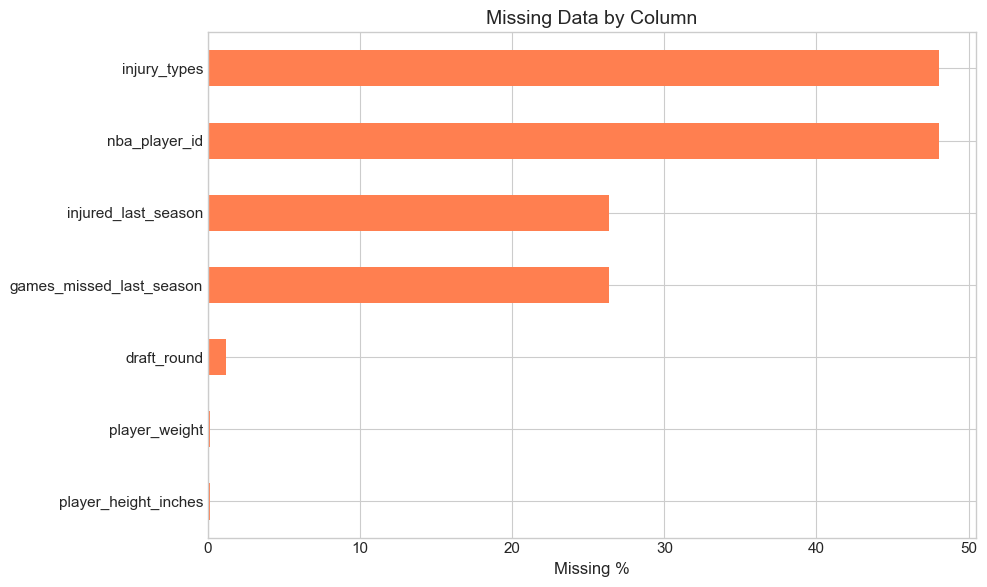

In [31]:
# Visualize missing data
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_pct.head(15).plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Data by Column')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

In [32]:
# Injury data merge coverage
injury_coverage = (df_analysis['games_missed'] > 0).sum()
original_injuries = len(df_injuries)

print(f"\nInjury Data Merge Coverage:")
print(f"  Original injury records: {original_injuries}")
print(f"  Matched to player stats: {injury_coverage}")
print(f"  Coverage: {injury_coverage/original_injuries*100:.1f}%")


Injury Data Merge Coverage:
  Original injury records: 2622
  Matched to player stats: 2562
  Coverage: 97.7%


---
## Section 8: Key Figures Summary

Quick inventory of all publication-quality figures saved during this EDA.

In [33]:
# List all saved figures
print("Figures saved to figures/ directory:")
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {f.name}")

Figures saved to figures/ directory:
  - correlation_heatmap.png
  - injury_by_age_position.png
  - injury_trend_by_season.png
  - prior_injury_vs_future.png
  - target_distribution.png
  - workload_vs_injury.png


---
## Section 9: Summary & Key Findings

In [34]:
# Generate summary statistics for report
print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print("\n1. TARGET VARIABLE (games_missed):")
print(f"   - Mean: {df_analysis['games_missed'].mean():.2f} games")
print(f"   - Median: {df_analysis['games_missed'].median():.0f} games")
print(f"   - Std: {df_analysis['games_missed'].std():.2f}")
print(f"   - Skewness: {df_analysis['games_missed'].skew():.2f} (highly right-skewed)")
print(f"   - Zero-inflation: {(df_analysis['games_missed']==0).mean()*100:.1f}% have 0 games missed")

print("\n2. TOP CORRELATED FEATURES:")
for i, (feat, corr) in enumerate(target_corr.head(5).items()):
    print(f"   {i+1}. {feat}: r={corr:.3f}")

print("\n3. KEY HYPOTHESIS - Prior Injury Predicts Future Injury:")
print(f"   - Correlation (games_missed_last_season vs games_missed): r={prior_injury_corr:.3f}")
print(f"   - If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% injury rate")
print(f"   - If injured last season: {repeat_injury_rate[1]*100:.1f}% injury rate")

print("\n4. AGE EFFECT:")
age_effect = df_analysis.groupby('age_group', observed=False)['games_missed'].mean()
for age_grp, mean_missed in age_effect.items():
    print(f"   - {age_grp}: {mean_missed:.2f} mean games missed")

EDA SUMMARY

1. TARGET VARIABLE (games_missed):
   - Mean: 1.67 games
   - Median: 1 games
   - Std: 3.17
   - Skewness: 4.48 (highly right-skewed)
   - Zero-inflation: 48.1% have 0 games missed

2. TOP CORRELATED FEATURES:
   1. min: r=0.220
   2. tov: r=0.205
   3. pts: r=0.180
   4. stl: r=0.159
   5. ast: r=0.148

3. KEY HYPOTHESIS - Prior Injury Predicts Future Injury:
   - Correlation (games_missed_last_season vs games_missed): r=0.213
   - If NOT injured last season: 43.1% injury rate
   - If injured last season: 64.2% injury rate

4. AGE EFFECT:
   - Under 25: 1.31 mean games missed
   - 25-30: 1.93 mean games missed
   - Over 30: 2.04 mean games missed


### Key Findings

1. **Target variable** is highly right-skewed (skewness ~4.48) with ~48% zero-inflation
2. **Minutes played** (r≈0.220) is the strongest raw predictor of games missed
3. **Prior injury predicts future injury** — players injured last season have ~1.5x higher injury rate
4. **Age effect** is modest (r≈0.094) but compounds with workload
5. **Collinearity** — pts, tov, stl, ast are highly correlated with minutes

### Observations for Feature Engineering

- An `age x minutes` interaction term may capture compounding risk better than either alone
- Back-to-back game counts from schedule data could serve as a fatigue proxy
- Tracking data (2013+) and hustle stats (2016+) have partial coverage — worth evaluating trade-offs
- Prior season injury (`games_missed_last_season`) is a strong lag feature candidate

### Key Takeaways for Modeling

Actionable insights from this EDA that directly inform our modeling strategy:

1. **Target is zero-inflated and right-skewed** — consider a two-stage model (classify injured vs. not, then predict severity) or robust regression methods. Standard linear regression will struggle with the ~48% zero mass.

2. **Top predictive features:** minutes played, age x minutes interaction, back-to-back games (from schedule data), and prior injury history (`games_missed_last_season`).

3. **Tracking data missing for 2010-2012 (~28% of player-seasons)** — handle in feature engineering with either: (a) separate models with/without tracking features, (b) imputation, or (c) restrict to 2013+ for models using tracking data.

4. **High collinearity among pts/tov/stl/ast with minutes** — these are all workload derivatives. Drop the redundant ones or use minutes as a single workload proxy to avoid multicollinearity in linear models.

5. **Prior injury is the strongest single signal (~1.5x risk increase)** — `games_missed_last_season` and `injured_last_season` (binary) should both be considered as lag features. This also means the forward-shifted target (`games_missed_next_season`) is critical.

In [35]:
# Save the analysis dataframe for feature engineering
# Drop redundant _rank columns (league-wide ranking columns from nba_api)
rank_cols = [c for c in df_analysis.columns if c.endswith('_rank')]
print(f"Dropping {len(rank_cols)} redundant _rank columns: {rank_cols[:5]}...")

df_output = df_analysis.drop(columns=rank_cols)

output_path = f'../{PROCESSED_DIR}/analysis_merged.csv'
df_output.to_csv(output_path, index=False)
print(f"\nSaved merged analysis data: {output_path}")
print(f"Shape: {df_output.shape}")
print(f"Columns ({len(df_output.columns)}): {list(df_output.columns)}")

Dropping 30 redundant _rank columns: ['gp_rank', 'w_rank', 'l_rank', 'w_pct_rank', 'min_rank']...

Saved merged analysis data: ../data/processed/analysis_merged.csv
Shape: (4935, 60)
Columns (60): ['player_id', 'player_name', 'nickname', 'team_id', 'team_abbreviation', 'age', 'gp', 'w', 'l', 'w_pct', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd', 'pts', 'plus_minus', 'nba_fantasy_pts', 'dd2', 'td3', 'wnba_fantasy_pts', 'team_count', 'season', 'season_start_year', 'player_name_clean', 'nba_player_id', 'games_missed', 'injury_events', 'injury_types', 'player_height_inches', 'player_weight', 'country', 'draft_year', 'draft_round', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'age_group', 'position_group', 'games_missed_last_season', 'injured_this_season', 'injured_last_season']


---
## Handoff to Notebook 04 (Feature Engineering)

### Files produced by this notebook
- **`data/processed/analysis_merged.csv`** — unified player-season DataFrame (all EDA columns minus redundant `_rank` columns)
- **`figures/`** — 6 publication-quality figures:
  - `target_distribution.png` — games_missed histogram (all + injured-only)
  - `injury_trend_by_season.png` — league-wide injury trends 2010-2019
  - `injury_by_age_position.png` — heatmap of injury risk by age group and position
  - `correlation_heatmap.png` — top feature correlations with games_missed
  - `prior_injury_vs_future.png` — scatter plot of prior season injury as predictor
  - `workload_vs_injury.png` — minutes per game vs mean games missed

### What NB04 needs to do
1. **Create forward-shifted target:** `games_missed_next_season` — shift `games_missed` forward by one season per player so we predict *future* injury from *current* features
2. **Handle 2019-20:** The 2019-20 season has only 1 game missed in the injury data (data ends July 2019). Exclude it as a feature source or flag it appropriately
3. **Train/test split:** Train on 2010-2017, test on 2018-2019 (per config.py)
4. **Handle tracking data missingness:** Tracking stats only available 2013-2019 (~28% of player-seasons missing). Decide on imputation, separate models, or restrict timeframe
5. **Feature creation:** `age x minutes` interaction, back-to-back game aggregation per player-season, lag features from prior season
6. **Drop collinear features:** pts/tov/stl/ast are workload derivatives of minutes

### Known limitations carried forward
- Position grouping is height-based (approximation) — raw position data not in the stats endpoint
- 2011-12 lockout season has 66 games instead of 82, which compresses injury counts
- Hustle stats only available 2016-2019 (4 of 10 seasons)